# Binary Classification using XGBoost

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import plotly.express as px
from sklearn.metrics import confusion_matrix, recall_score
import joblib
import os


## EDA

In [2]:
df = pd.read_csv('../data/train_data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(559, 33)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,559.0,3.055431e+07,1.260425e+08,8670.000000,869051.500000,906024.00000,8.813003e+06,9.113205e+08
radius_mean,559.0,1.411178e+01,3.524193e+00,6.981000,11.695000,13.34000,1.575000e+01,2.811000e+01
texture_mean,559.0,1.928023e+01,4.236680e+00,9.710000,16.195000,18.87000,2.181500e+01,3.381000e+01
perimeter_mean,559.0,9.185487e+01,2.430726e+01,43.790000,75.015000,86.18000,1.037000e+02,1.885000e+02
area_mean,559.0,6.535270e+02,3.522989e+02,143.500000,419.250000,546.40000,7.772500e+02,2.501000e+03
smoothness_mean,559.0,9.630422e-02,1.408518e-02,0.052630,0.086210,0.09586,1.053000e-01,1.634000e-01
compactness_mean,559.0,1.040401e-01,5.274468e-02,0.019380,0.063750,0.09242,1.304000e-01,3.454000e-01
concavity_mean,559.0,8.833093e-02,7.957889e-02,0.000000,0.029320,0.06126,1.269500e-01,4.268000e-01
concave points_mean,559.0,4.874528e-02,3.889630e-02,0.000000,0.020290,0.03334,7.352000e-02,2.012000e-01
symmetry_mean,559.0,1.810231e-01,2.729117e-02,0.106000,0.161900,0.17920,1.956500e-01,3.040000e-01


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       559 non-null    int64  
 1   diagnosis                559 non-null    str    
 2   radius_mean              559 non-null    float64
 3   texture_mean             559 non-null    float64
 4   perimeter_mean           559 non-null    float64
 5   area_mean                559 non-null    float64
 6   smoothness_mean          559 non-null    float64
 7   compactness_mean         559 non-null    float64
 8   concavity_mean           559 non-null    float64
 9   concave points_mean      559 non-null    float64
 10  symmetry_mean            559 non-null    float64
 11  fractal_dimension_mean   559 non-null    float64
 12  radius_se                559 non-null    float64
 13  texture_se               559 non-null    float64
 14  perimeter_se             559 non-null

In [7]:
df['diagnosis'].value_counts(normalize=True)

diagnosis
B    0.629696
M    0.370304
Name: proportion, dtype: float64

## Data Preprocessing (Cleaning)

- Dropping `id` and `Unnamed: 32`
- Relabelling `M` and `B` to 1 and 0 respectively

In [8]:
df.drop('id',axis=1,inplace=True)
df.drop('Unnamed: 32',axis=1,inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Data Splitting
- 80-20 split (80 train, 20 test)

In [9]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=123)
train_df['diagnosis'].value_counts(normalize=True)

diagnosis
0    0.630872
1    0.369128
Name: proportion, dtype: float64

In [10]:
X_train = train_df.drop(columns=['diagnosis'])
y_train = train_df['diagnosis']
X_test = test_df.drop(columns=['diagnosis'])
y_test = test_df['diagnosis']

X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
430,14.02,15.66,89.59,606.5,0.07966,0.05581,0.02087,0.026520,0.1589,0.05586,...,14.91,19.31,96.53,688.9,0.10340,0.10170,0.06260,0.08216,0.2136,0.06710
249,13.96,17.05,91.43,602.4,0.10960,0.12790,0.09789,0.052460,0.1908,0.06130,...,16.39,22.07,108.10,826.0,0.15120,0.32620,0.32090,0.13740,0.3068,0.07957
348,11.14,14.07,71.24,384.6,0.07274,0.06064,0.04505,0.014710,0.1690,0.06083,...,12.12,15.82,79.62,453.5,0.08864,0.12560,0.12010,0.03922,0.2576,0.07018
416,10.03,21.28,63.19,307.3,0.08117,0.03912,0.00247,0.005159,0.1630,0.06439,...,11.11,28.94,69.92,376.3,0.11260,0.07094,0.01235,0.02579,0.2349,0.08061
74,16.07,19.65,104.10,817.7,0.09168,0.08424,0.09769,0.066380,0.1798,0.05391,...,19.77,24.56,128.80,1223.0,0.15000,0.20450,0.28290,0.15200,0.2650,0.06387


## Model Building

In [11]:
# Calculate the ratio of negative to positive cases
b_count = (y_train == 0).sum()
m_count = (y_train == 1).sum()
weight_ratio = b_count / m_count

In [12]:
xgb_model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=4, 
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=weight_ratio # heavily penalize itself every time it misclassifies the positive class (Malignant)
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Recall Score (Sensitivity): 0.9524
This means the model successfully identified 95.2% of all actual Malignant cases.


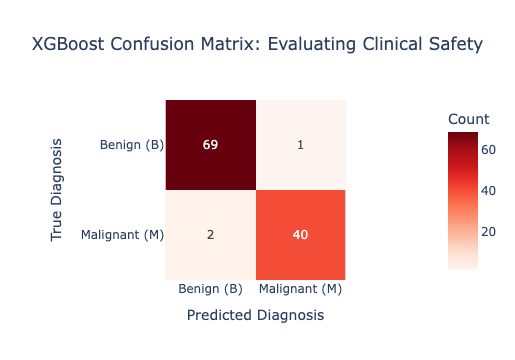

In [13]:
# 1. Generate predictions on your test set
y_pred = xgb_model.predict(X_test)

# 2. Calculate the Recall Score
# In our LabelEncoder, Malignant (M) is 1, so it is the "positive" class we want to recall
recall = recall_score(y_test, y_pred)
print(f"Recall Score (Sensitivity): {recall:.4f}")
print(f"This means the model successfully identified {recall*100:.1f}% of all actual Malignant cases.")

# 3. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Visualize with Plotly
fig_cm = px.imshow(
    cm,
    text_auto=True, # Automatically adds the numbers inside the boxes
    color_continuous_scale='Reds', # Red highlights the "danger" areas well
    labels=dict(x="Predicted Diagnosis", y="True Diagnosis", color="Count"),
    x=['Benign (B)', 'Malignant (M)'],
    y=['Benign (B)', 'Malignant (M)'],
    title="XGBoost Confusion Matrix: Evaluating Clinical Safety"
)

# Tweak layout for better readability
fig_cm.update_layout(title_x=0.5)
fig_cm.show()

In [14]:
accuracy = xgb_model.score(X_test, y_test)
print(f"XGBoost Baseline Accuracy: {accuracy:.4f}")

XGBoost Baseline Accuracy: 0.9732


## Prediction Confidence

In [15]:
import pandas as pd
import plotly.express as px

# 1. Get the raw probabilities
# .predict_proba returns [[Prob_Benign, Prob_Malignant], ...]
# We slice [:, 1] to grab just the Malignant probabilities
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. Create a DataFrame to see everything side-by-side
results_df = pd.DataFrame({
    'True_Diagnosis': y_test,          # 1 for M, 0 for B
    'Predicted_Class': y_pred,         # What the model guessed
    'Malignant_Probability': y_proba   # The confidence score (0.0 to 1.0)
})

# Let's map the 0/1 back to B/M for cleaner charting
results_df['True_Diagnosis_Label'] = results_df['True_Diagnosis'].map({1: 'Malignant (M)', 0: 'Benign (B)'})

# Take a look at the first few rows
print(results_df.head())

     True_Diagnosis  Predicted_Class  Malignant_Probability  \
275               0                0               0.004532   
75                0                0               0.002877   
202               1                1               0.681852   
196               1                1               0.997316   
260               0                0               0.000711   

    True_Diagnosis_Label  
275           Benign (B)  
75            Benign (B)  
202        Malignant (M)  
196        Malignant (M)  
260           Benign (B)  


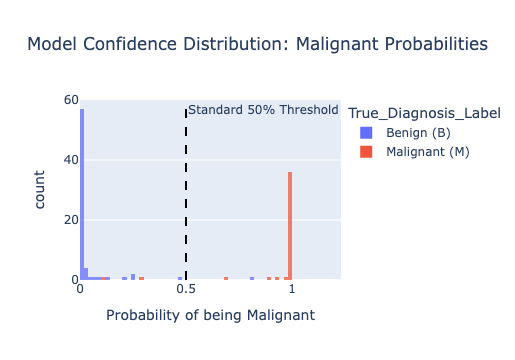

In [16]:
# 3. Plotly Histogram of Probabilities
fig_prob = px.histogram(
    results_df, 
    x="Malignant_Probability", 
    color="True_Diagnosis_Label",
    nbins=50,
    color_discrete_map={"Malignant (M)": "#ef553b", "Benign (B)": "#636efa"},
    title="Model Confidence Distribution: Malignant Probabilities",
    labels={"Malignant_Probability": "Probability of being Malignant", "count": "Number of Patients"},
    barmode="overlay",
    opacity=0.75
)

# Add a vertical dashed line at the standard 0.5 decision threshold
fig_prob.add_vline(x=0.5, line_dash="dash", line_color="black", annotation_text="Standard 50% Threshold")

fig_prob.update_layout(title_x=0.5)
fig_prob.show()

In [17]:
analysis_df = pd.DataFrame({
    'True_Diagnosis': y_test,
    'Predicted_Diagnosis': y_pred,
    'Malignant_Probability': y_proba
})

# 3. Filter for ONLY the mislabeled predictions
mislabeled_df = analysis_df[analysis_df['True_Diagnosis'] != analysis_df['Predicted_Diagnosis']].copy()

# 4. Add a descriptive error type
def get_error_type(row):
    if row['True_Diagnosis'] == 1 and row['Predicted_Diagnosis'] == 0:
        return "False Negative (Missed Cancer)"
    elif row['True_Diagnosis'] == 0 and row['Predicted_Diagnosis'] == 1:
        return "False Positive (False Alarm)"
    return "Unknown"

mislabeled_df['Error_Type'] = mislabeled_df.apply(get_error_type, axis=1)

# 5. Display the results, sorted by probability
print(f"Total Misclassifications: {len(mislabeled_df)}")
print("-" * 50)
print(mislabeled_df[['Error_Type', 'True_Diagnosis', 'Malignant_Probability']].sort_values(by='Malignant_Probability', ascending=False).to_string(index=False))

Total Misclassifications: 3
--------------------------------------------------
                    Error_Type  True_Diagnosis  Malignant_Probability
  False Positive (False Alarm)               0               0.803563
False Negative (Missed Cancer)               1               0.281925
False Negative (Missed Cancer)               1               0.106456


## Feature Importance

In [18]:
# 3. Extract Feature Importance
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

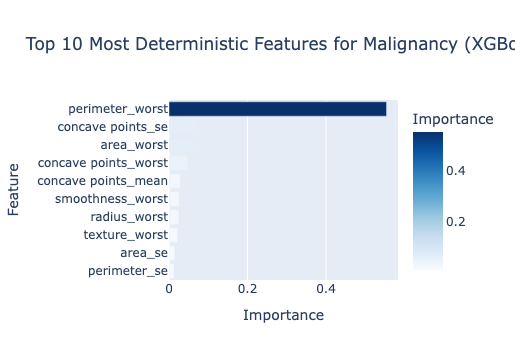

In [19]:
# 4. Plotly Visualization
fig = px.bar(
    fi_df, 
    x='Importance', 
    y='Feature', 
    orientation='h',
    title="Top 10 Most Deterministic Features for Malignancy (XGBoost)",
    color='Importance',
    color_continuous_scale='Blues' # Swapped to Blues for a fresh look
)

# Reverse the y-axis so the most important is at the top
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

## Save model

In [20]:
# Save the XGBoost model to disk
model_path = '../models/xgb_cancer_model.joblib'
joblib.dump(xgb_model, model_path)

print(f"Model successfully saved to {model_path}")

Model successfully saved to ../models/xgb_cancer_model.joblib


## Findings

Our XGBoost model caught 95% of cases, but we discovered that 2 specific patients had tumors that perfectly mimicked healthy tissue, completely fooling the supervised AI. This is why a black-box model isn't enough. By plotting the patient on our 2D feature map, a doctor can visually see if a 'Benign' prediction is actually sitting right in the middle of a Malignant cluster, catching the AI's mistake before the patient is sent home.